In [1]:
# Import libraries for data analysis
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for splitting and preprocessing the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Import the classification model
from sklearn.ensemble import RandomForestClassifier

# Import classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Import permutation importance
from sklearn.inspection import permutation_importance

In [2]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week07/Car_Insurance_Claim.csv'

In [3]:
df = pd.read_csv(fpath)
df

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,323164,26-39,female,majority,10-19y,university,upper class,0.582787,1.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,1,0.0
9996,910346,26-39,female,majority,10-19y,none,middle class,0.522231,1.0,after 2015,0.0,1.0,32765,NaN,sedan,1,0,0,0.0
9997,468409,26-39,male,majority,0-9y,high school,middle class,0.470940,1.0,before 2015,0.0,1.0,10238,14000.0,sedan,0,0,0,0.0
9998,903459,26-39,female,majority,10-19y,high school,poverty,0.364185,0.0,before 2015,0.0,1.0,10238,13000.0,sedan,2,0,1,1.0


In [4]:
# Check the dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 19


In [5]:
# Display column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

In [6]:
# Check the number of missing values in each column
df.isna().sum()

,0
ID,0
AGE,0
GENDER,0
RACE,0
DRIVING_EXPERIENCE,0
EDUCATION,0
INCOME,0
CREDIT_SCORE,982
VEHICLE_OWNERSHIP,0
VEHICLE_YEAR,0


In [7]:
# Check for duplicated rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Display summary statistics for numeric features
df.describe()

,ID,CREDIT_SCORE,VEHICLE_OWNERSHIP,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
count,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [9]:
# Check the distribution of the target
df["OUTCOME"].value_counts()
df["OUTCOME"].value_counts(normalize=True) * 100

,proportion
OUTCOME,
0.0,68.67
1.0,31.33


In [10]:
# Drop the ID column because it is only a unique identifier
df = df.drop(columns="ID")

In [11]:
# Convert the postal code into a categorical feature
df["POSTAL_CODE"] = df["POSTAL_CODE"].astype("object")

In [12]:
# Display the values in each categorical column
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"{column}:")
    print(df[column].value_counts())
    print()

AGE:
AGE
26-39    3063
40-64    2931
16-25    2016
65+      1990
Name: count, dtype: int64

GENDER:
GENDER
female    5010
male      4990
Name: count, dtype: int64

RACE:
RACE
majority    9012
minority     988
Name: count, dtype: int64

DRIVING_EXPERIENCE:
DRIVING_EXPERIENCE
0-9y      3530
10-19y    3299
20-29y    2119
30y+      1052
Name: count, dtype: int64

EDUCATION:
EDUCATION
high school    4157
university     3928
none           1915
Name: count, dtype: int64

INCOME:
INCOME
upper class      4336
middle class     2138
poverty          1814
working class    1712
Name: count, dtype: int64

VEHICLE_YEAR:
VEHICLE_YEAR
before 2015    6967
after 2015     3033
Name: count, dtype: int64

POSTAL_CODE:
POSTAL_CODE
10238    6940
32765    2456
92101     484
21217     120
Name: count, dtype: int64

VEHICLE_TYPE:
VEHICLE_TYPE
sedan         9523
sports car     477
Name: count, dtype: int64



## Data Overview and Cleaning

The dataset contains 10,000 rows and 19 columns. Each row represents a car insurance customer, and the target is `OUTCOME`, which indicates whether the customer made an insurance claim.

The data was inspected for missing values, duplicated rows, data types, and inconsistent categorical values. No duplicated rows or inconsistent category labels were found.

The `ID` column was removed because it is only a unique identifier and does not provide useful information for predicting insurance claims. `POSTAL_CODE` was treated as a categorical feature because it represents a geographic area rather than a measurable numerical value.

Missing values were found in `CREDIT_SCORE` and `ANNUAL_MILEAGE`. These values will be handled later within the preprocessing pipeline to prevent data leakage.

The target contains two classes:

- `0`: The customer did not make an insurance claim.
- `1`: The customer made an insurance claim.

Approximately 68.67% of the customers did not make a claim, while 31.33% made a claim. This indicates a moderate class imbalance, which will be considered during model evaluation.

## Exploratory Data Analysis

Exploratory visualizations will be used to understand the distribution of the data and investigate how customer, vehicle, and driving-related characteristics are associated with insurance claims.

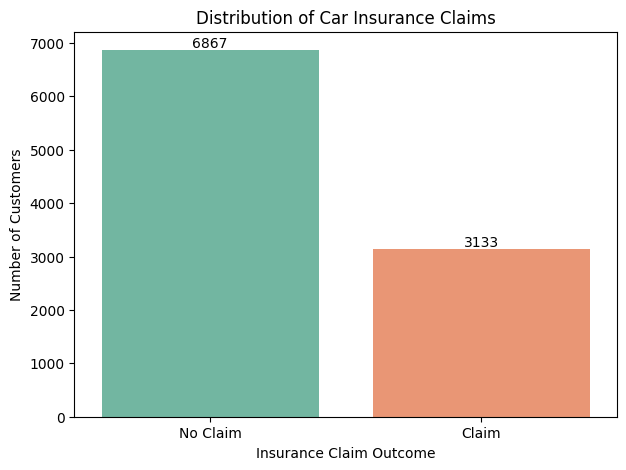

In [13]:
# Visualize the distribution of the target
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="OUTCOME", hue="OUTCOME", palette="Set2", legend=False)

plt.title("Distribution of Car Insurance Claims")
plt.xlabel("Insurance Claim Outcome")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Claim", "Claim"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The dataset contains 6,867 customers who did not make an insurance claim and 3,133 customers who did. Therefore, approximately 31% of the customers made a claim. This shows a moderate class imbalance, so model performance should be evaluated using metrics such as recall and F1-score in addition to accuracy.

In [14]:
# Calculate the claim rate for each driving experience group
experience_claim_rate = df.groupby("DRIVING_EXPERIENCE")["OUTCOME"].mean() * 100

experience_claim_rate

,OUTCOME
DRIVING_EXPERIENCE,
0-9y,62.804533
10-19y,23.855714
20-29y,5.143936
30y+,1.901141


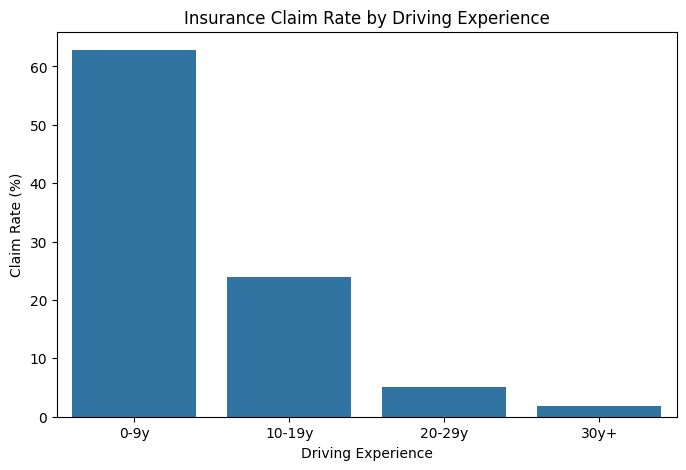

In [15]:
# Visualize the claim rate by driving experience
plt.figure(figsize=(8, 5))

sns.barplot(
    x=experience_claim_rate.index,
    y=experience_claim_rate.values,
    order=["0-9y", "10-19y", "20-29y", "30y+"]
)

plt.title("Insurance Claim Rate by Driving Experience")
plt.xlabel("Driving Experience")
plt.ylabel("Claim Rate (%)")
plt.show()

The insurance claim rate decreases significantly as driving experience increases. Customers with 0–9 years of experience have the highest claim rate at approximately 63%, compared with about 24% for customers with 10–19 years of experience. The rate falls to approximately 5% for those with 20–29 years of experience and 2% for those with 30 or more years. This suggests that driving experience may be an important factor in identifying customers with a higher likelihood of making an insurance claim.

In [16]:
# Calculate the claim rate for each age group
age_claim_rate = df.groupby("AGE")["OUTCOME"].mean() * 100

age_claim_rate

,OUTCOME
AGE,
16-25,71.825397
26-39,33.692458
40-64,15.591948
65+,9.849246


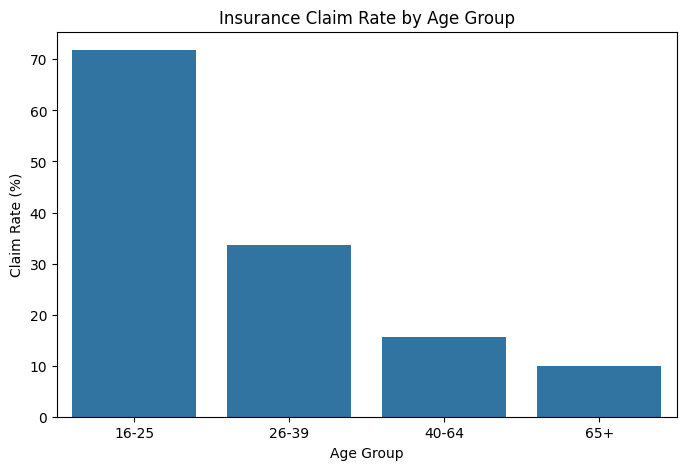

In [17]:
# Visualize the claim rate by age group
plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_claim_rate.index,
    y=age_claim_rate.values,
    order=["16-25", "26-39", "40-64", "65+"]
)

plt.title("Insurance Claim Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Claim Rate (%)")
plt.show()

The insurance claim rate decreases as customer age increases. Customers aged 16–25 have the highest claim rate at approximately 72%, followed by about 34% for customers aged 26–39. The rate decreases to approximately 16% for customers aged 40–64 and 10% for those aged 65 or older. This suggests that age may be an important factor in predicting insurance claims, with younger customers showing a higher likelihood of making a claim.

In [18]:
# Calculate the claim rate based on vehicle ownership
ownership_claim_rate = df.groupby("VEHICLE_OWNERSHIP")["OUTCOME"].mean() * 100

ownership_claim_rate

,OUTCOME
VEHICLE_OWNERSHIP,
0.0,57.986799
1.0,19.741750


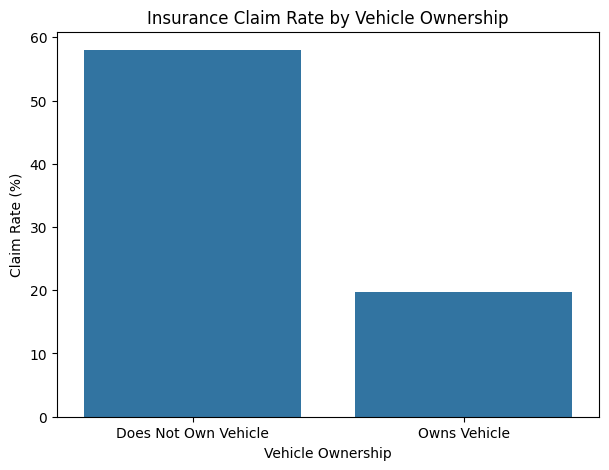

In [19]:
# Visualize the claim rate by vehicle ownership
plt.figure(figsize=(7, 5))

sns.barplot(
    x=ownership_claim_rate.index,
    y=ownership_claim_rate.values
)

plt.title("Insurance Claim Rate by Vehicle Ownership")
plt.xlabel("Vehicle Ownership")
plt.ylabel("Claim Rate (%)")
plt.xticks([0, 1], ["Does Not Own Vehicle", "Owns Vehicle"])
plt.show()

Customers who do not own their vehicles have a claim rate of approximately 58%, compared with about 20% among customers who own their vehicles. This indicates a noticeable relationship between vehicle ownership and insurance claims, suggesting that vehicle ownership may help the model distinguish between higher-risk and lower-risk customers.

In [20]:
# Calculate the claim rate based on vehicle year
vehicle_year_claim_rate = df.groupby("VEHICLE_YEAR")["OUTCOME"].mean() * 100

vehicle_year_claim_rate

,OUTCOME
VEHICLE_YEAR,
after 2015,10.649522
before 2015,40.332998


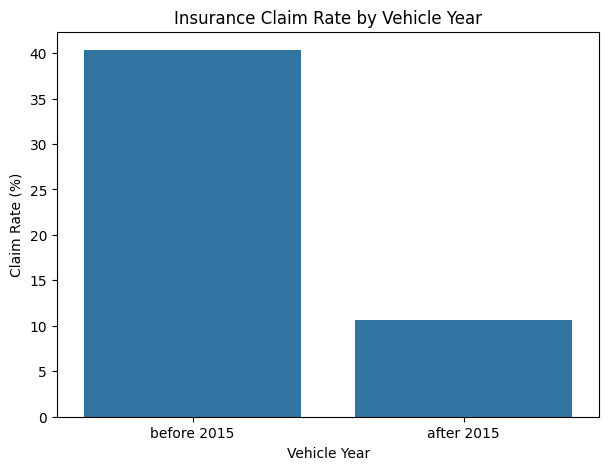

In [21]:
# Visualize the claim rate by vehicle year
plt.figure(figsize=(7, 5))

sns.barplot(
    x=vehicle_year_claim_rate.index,
    y=vehicle_year_claim_rate.values,
    order=["before 2015", "after 2015"]
)

plt.title("Insurance Claim Rate by Vehicle Year")
plt.xlabel("Vehicle Year")
plt.ylabel("Claim Rate (%)")
plt.show()

Customers with vehicles manufactured before 2015 have a claim rate of approximately 40%, compared with about 11% for customers with vehicles manufactured after 2015. This clear difference shows that customers with older vehicles are more likely to make an insurance claim. Therefore, vehicle year may be an important feature for predicting insurance claims.

## Model Preparation

The data will now be divided into features (`X`) and the target (`y`). The target is `OUTCOME`, while the remaining columns will be used to predict whether a customer will make an insurance claim.

The data will be split into training and testing sets. Stratification will be used to maintain the same proportion of claim and no-claim customers in both sets.

In [22]:
# Separate the features from the target
X = df.drop(columns="OUTCOME")
y = df["OUTCOME"]

In [23]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [24]:
# Display the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7500, 17)
X_test shape: (2500, 17)
y_train shape: (7500,)
y_test shape: (2500,)


## Data Preprocessing

The features contain both numerical and categorical data. Separate preprocessing steps will be applied to each type.

Missing numerical values will be replaced using the median, and numerical features will be scaled using `StandardScaler`. Categorical features will be encoded using `OneHotEncoder` so they can be used by the machine learning model.

In [25]:
# Select the numerical and categorical columns
numeric_columns = X_train.select_dtypes(include="number").columns
categorical_columns = X_train.select_dtypes(include="object").columns

In [26]:
# Create the numerical preprocessing pipeline
numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# Create the categorical preprocessing pipeline
categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

In [27]:
# Apply the appropriate preprocessing to each column type
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_columns),
    ('cat', categorical_pipeline, categorical_columns)]
)

## Default Classification Model

A default Random Forest Classifier will be used to predict whether a customer will make an insurance claim. The preprocessing steps and the model will be combined in one pipeline to ensure that the same transformations are applied consistently during training and testing.

In [28]:
# Combine the preprocessor and the default Random Forest model
rf_model = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

In [29]:
# Train the model using the training data
rf_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN',
       'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['AGE', 'GENDER', 'RACE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME',
       'VEHICLE_YEAR', 'POSTAL_CODE', 'VEHICLE_TYPE'],
      dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

## Model Evaluation

The model will be evaluated on both the training and testing data using precision, recall, F1-score, and accuracy. Comparing the two reports will help identify whether the model generalizes well or overfits the training data. A confusion matrix will also be used to examine the model's correct and incorrect test predictions.

In [30]:
# Define a function to evaluate classification models
def evaluate_model(model, X_train, y_train, X_test, y_test):

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("Training Classification Report")
    print(classification_report(y_train, y_pred_train))

    print()

    print("Test Classification Report")
    print(classification_report(y_test, y_pred_test))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
    plt.title("Test Confusion Matrix")
    plt.show()

Training Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5150
         1.0       1.00      1.00      1.00      2350

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500


Test Classification Report
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87      1717
         1.0       0.73      0.70      0.71       783

    accuracy                           0.82      2500
   macro avg       0.80      0.79      0.79      2500
weighted avg       0.82      0.82      0.82      2500



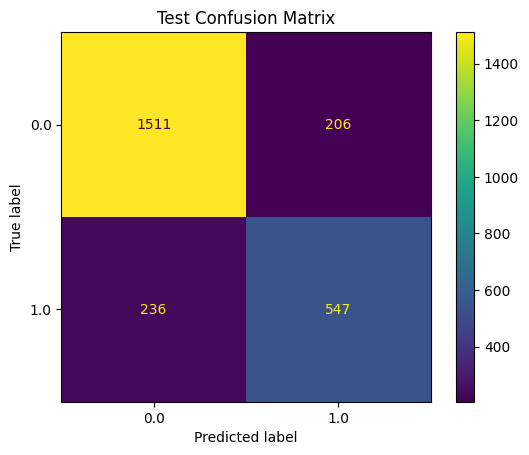

In [31]:
# Evaluate the default Random Forest model
evaluate_model(rf_model, X_train, y_train, X_test, y_test)

The default Random Forest achieved 100% accuracy on the training data and 82% accuracy on the testing data. The difference between the training and testing performance indicates that the model is overfitting the training data.

Because the target classes are moderately imbalanced, accuracy was not considered alone. For customers who made a claim (class 1), the model achieved 73% precision, 70% recall, and a 71% F1-score. The confusion matrix shows that the model correctly identified 547 customers who made a claim but missed 236 claim cases. It also incorrectly predicted claims for 206 customers who did not make a claim.

Overall, the model provides reasonable test performance, but it misses approximately 30% of the actual claim cases. Its perfect training performance and lower testing performance show that it does not generalize equally well to unseen data.

## Permutation Feature Importance

Permutation importance will be used to measure how much each feature contributes to the model's test performance. A feature is considered important when randomly changing its values causes a noticeable decrease in model performance.

In [32]:
# Calculate permutation importance using the testing data
permutation_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

In [33]:
# Store the feature names and their importance scores
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation_result.importances_mean
})

In [34]:
# Select the ten most important features
top_10_features = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

top_10_features

,Feature,Importance
3,DRIVING_EXPERIENCE,5.400000e-02
8,VEHICLE_YEAR,3.428000e-02
7,VEHICLE_OWNERSHIP,3.112000e-02
11,POSTAL_CODE,2.632000e-02
1,GENDER,1.120000e-02
14,SPEEDING_VIOLATIONS,2.800000e-04
13,VEHICLE_TYPE,4.440892e-17
9,MARRIED,-2.000000e-04
12,ANNUAL_MILEAGE,-3.600000e-04
2,RACE,-5.200000e-04


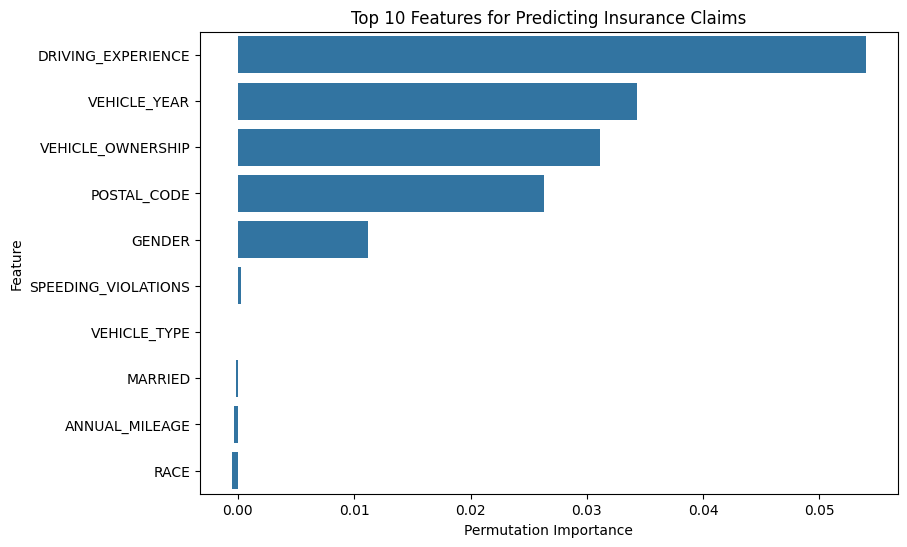

In [35]:
# Visualize the ten most important features
plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_10_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features for Predicting Insurance Claims")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

Driving experience is the most important feature for predicting insurance claims, followed by vehicle year, vehicle ownership, postal code, and gender. These results generally make sense for the business case because driving experience and vehicle-related characteristics can help an insurance company assess the likelihood of a customer making a claim.

Speeding violations had only a small effect on the model's performance, while vehicle type, marital status, annual mileage, and race provided little or no additional predictive value. The slightly negative importance values indicate that randomly changing these features did not reduce the model's performance and may have slightly improved it, suggesting that they are not useful to this model.

## Explanatory Visualizations

The two most important features identified by permutation importance were `DRIVING_EXPERIENCE` and `VEHICLE_YEAR`. The following visualizations show how each feature is related to the insurance claim outcome.

In [36]:
# Calculate the claim rate for each driving experience group
experience_claim_rate = df.groupby("DRIVING_EXPERIENCE")["OUTCOME"].mean() * 100
experience_claim_rate


,OUTCOME
DRIVING_EXPERIENCE,
0-9y,62.804533
10-19y,23.855714
20-29y,5.143936
30y+,1.901141


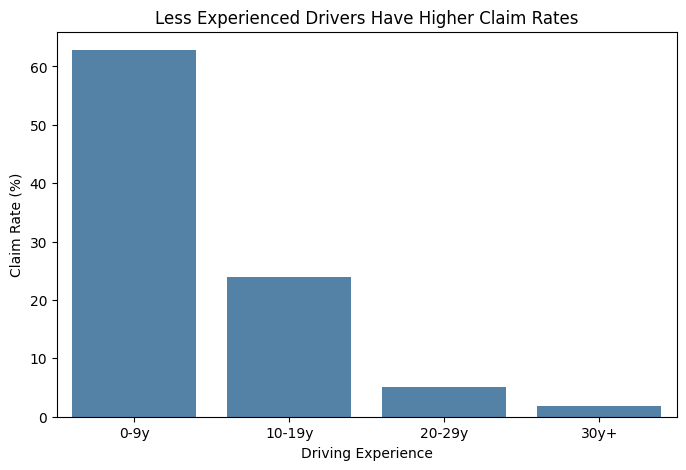

In [37]:
# Visualize the claim rate by driving experience
plt.figure(figsize=(8, 5))

sns.barplot(
    x=experience_claim_rate.index,
    y=experience_claim_rate.values,
    order=["0-9y", "10-19y", "20-29y", "30y+"],
    color="steelblue"
)

plt.title("Less Experienced Drivers Have Higher Claim Rates")
plt.xlabel("Driving Experience")
plt.ylabel("Claim Rate (%)")
plt.savefig("claim_rate_by_driving_experience.png", dpi=300, bbox_inches="tight")
plt.show()

The claim rate decreases sharply as driving experience increases. Customers with 0–9 years of experience have the highest claim rate at approximately 63%, compared with 24% for those with 10–19 years, 5% for those with 20–29 years, and only 2% for those with 30 or more years of experience. This clear pattern shows that driving experience is useful for identifying customers with a higher likelihood of making a claim.


In [38]:
# Calculate the claim rate based on vehicle year
vehicle_year_claim_rate = df.groupby("VEHICLE_YEAR")["OUTCOME"].mean() * 100
vehicle_year_claim_rate

,OUTCOME
VEHICLE_YEAR,
after 2015,10.649522
before 2015,40.332998


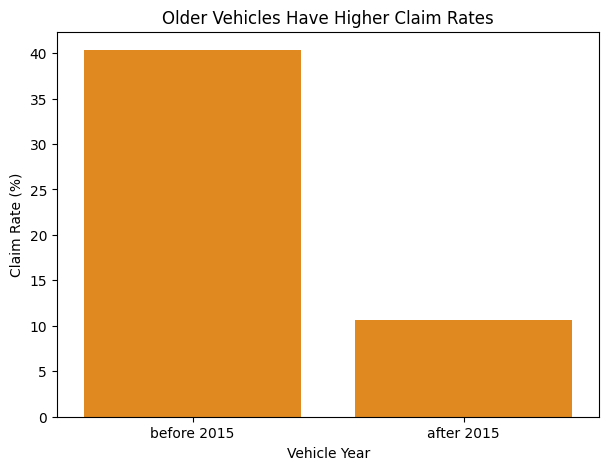

In [39]:
# Visualize the claim rate by vehicle year
plt.figure(figsize=(7, 5))

sns.barplot(
    x=vehicle_year_claim_rate.index,
    y=vehicle_year_claim_rate.values,
    order=["before 2015", "after 2015"],
    color="darkorange"
)

plt.title("Older Vehicles Have Higher Claim Rates")
plt.xlabel("Vehicle Year")
plt.ylabel("Claim Rate (%)")
plt.savefig("claim_rate_by_vehicle_year.png", dpi=300, bbox_inches="tight")
plt.show()

Customers with vehicles manufactured before 2015 have a claim rate of approximately 40.3%, compared with only 10.6% for customers with vehicles manufactured after 2015. This difference shows that customers with older vehicles are associated with a substantially higher likelihood of making an insurance claim, making vehicle year useful for insurance risk assessment.